# IBM HR Analytics — Employee Attrition EDA

**Track I1 — EDA & Visualization**

**Dataset:** IBM HR Analytics Employee Attrition & Performance (Kaggle, released by
IBM as a synthetic/sample dataset for HR analytics demonstrations — not real
employee records).

**Goal:** Understand what patterns in this dataset are associated with employee
attrition, using structured univariate and bivariate exploratory analysis.

## 1. Data Understanding

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)

df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")
print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(df.head())

Shape: 1470 rows, 35 columns
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   EnvironmentSatisfaction  Gender  HourlyRat

### 1.1 Data types, missing values, duplicates, and constant columns

Before any analysis, we check the structural quality of the data:
- **Data types** — are numeric columns actually numeric, categorical columns stored as text?
- **Missing values** — any nulls that need imputing or flagging?
- **Duplicate rows** — any exact repeats that would double-count observations?
- **Constant columns** — columns with only one unique value carry zero information and should be dropped.
- **ID integrity** — does `EmployeeNumber` uniquely identify each row, as an ID should?

In [4]:
print("--- Data types ---")
print(df.dtypes.value_counts())
print()

print("--- Missing values ---")
missing = df.isnull().sum()
print(f"Total missing values across all columns: {missing.sum()}")
print()

print("--- Duplicate rows ---")
print(f"Duplicate rows: {df.duplicated().sum()}")
print()

print("--- Columns with only 1 unique value (no information) ---")
constant_cols = [c for c in df.columns if df[c].nunique() == 1]
for c in constant_cols:
    print(f"  {c}: constant value = {df[c].unique()[0]}")
print()

print("--- EmployeeNumber uniqueness (should behave like an ID) ---")
print(f"Unique EmployeeNumber values: {df['EmployeeNumber'].nunique()} out of {len(df)} rows")
print()

print("--- Object (text) columns and their unique value counts ---")
obj_cols = df.select_dtypes(include=["object", "string"]).columns
for c in obj_cols:
    print(f"  {c}: {df[c].nunique()} unique values -> {list(df[c].unique())[:6]}")

--- Data types ---
int64    26
str       9
Name: count, dtype: int64

--- Missing values ---
Total missing values across all columns: 0

--- Duplicate rows ---
Duplicate rows: 0

--- Columns with only 1 unique value (no information) ---
  EmployeeCount: constant value = 1
  Over18: constant value = Y
  StandardHours: constant value = 80

--- EmployeeNumber uniqueness (should behave like an ID) ---
Unique EmployeeNumber values: 1470 out of 1470 rows

--- Object (text) columns and their unique value counts ---
  Attrition: 2 unique values -> ['Yes', 'No']
  BusinessTravel: 3 unique values -> ['Travel_Rarely', 'Travel_Frequently', 'Non-Travel']
  Department: 3 unique values -> ['Sales', 'Research & Development', 'Human Resources']
  EducationField: 6 unique values -> ['Life Sciences', 'Other', 'Medical', 'Marketing', 'Technical Degree', 'Human Resources']
  Gender: 2 unique values -> ['Female', 'Male']
  JobRole: 9 unique values -> ['Sales Executive', 'Research Scientist', 'Laboratory Tec

### 1.2 Cleaning decisions

Based on the checks above:
- Drop `EmployeeCount`, `Over18`, `StandardHours` — constant columns, zero information.
- Keep `EmployeeNumber` as an identifier only; excluded from statistical analysis.
- No missing values or duplicates to handle.

All further analysis uses `df_clean`, the cleaned working dataframe.

In [5]:
cols_to_drop = ["EmployeeCount", "Over18", "StandardHours"]
df_clean = df.drop(columns=cols_to_drop)

print(f"Dropped columns: {cols_to_drop}")
print(f"Shape before: {df.shape} -> Shape after: {df_clean.shape}")
print()
print("Remaining columns:")
print(list(df_clean.columns))

Dropped columns: ['EmployeeCount', 'Over18', 'StandardHours']
Shape before: (1470, 35) -> Shape after: (1470, 32)

Remaining columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


## 2. Univariate Analysis

### 2.1 Target variable: Attrition

Before looking at any predictor, we need to understand the target itself — how many
employees left, and how imbalanced that split is. Class imbalance matters a lot here:
if only ~5% of employees left, comparisons later (e.g. "average income for leavers vs
stayers") are comparing a small group against a much larger one, which affects how
confidently we can generalize from what we see.

--- Attrition counts ---
Attrition
No     1233
Yes     237
Name: count, dtype: int64

--- Attrition percentages ---
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


C:\Users\HomePC\AppData\Local\Temp\ipykernel_1968\2791764898.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="Attrition", order=["No", "Yes"], ax=ax,


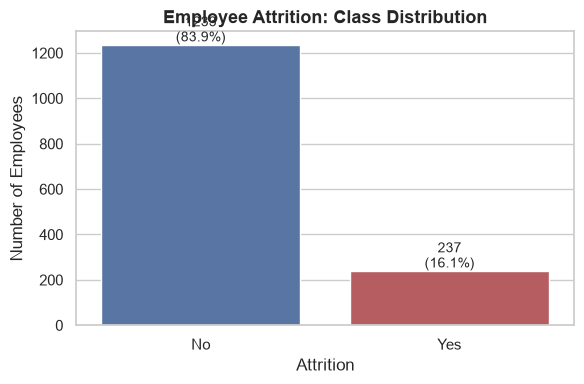

In [6]:
attrition_counts = df_clean["Attrition"].value_counts()
attrition_pct = df_clean["Attrition"].value_counts(normalize=True) * 100

print("--- Attrition counts ---")
print(attrition_counts)
print()
print("--- Attrition percentages ---")
print(attrition_pct.round(1))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=df_clean, x="Attrition", order=["No", "Yes"], ax=ax,
              palette=["#4C72B0", "#C44E52"])
ax.set_title("Employee Attrition: Class Distribution", fontsize=13, fontweight="bold")
ax.set_xlabel("Attrition")
ax.set_ylabel("Number of Employees")
for p in ax.patches:
    count = int(p.get_height())
    pct = count / len(df_clean) * 100
    ax.annotate(f"{count}\n({pct:.1f}%)", (p.get_x() + p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.show()

### 2.2 Numeric variables: overview

A quick statistical summary of all numeric columns — central tendency (mean, median),
spread (std, min/max), and quartiles. This tells us where to look closer for skew or
outliers before we chart anything.

In [7]:
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.drop("EmployeeNumber")
print(f"Numeric columns ({len(numeric_cols)}): {list(numeric_cols)}")
print()
print(df_clean[numeric_cols].describe().T.round(1))

Numeric columns (23): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

                           count     mean     std     min     25%      50%  \
Age                       1470.0     36.9     9.1    18.0    30.0     36.0   
DailyRate                 1470.0    802.5   403.5   102.0   465.0    802.0   
DistanceFromHome          1470.0      9.2     8.1     1.0     2.0      7.0   
Education                 1470.0      2.9     1.0     1.0     2.0      3.0   
EnvironmentSatisfaction   1470.0      2.7     1.1     1.0     2.0      3.0   
HourlyRate                1470.0     65.9    20.3    30.0    48.0

### 2.3 Distribution of Age

`Age` is a good variable to start with — it's a natural, well-behaved numeric field
with no obvious data issues. A histogram with a KDE (kernel density estimate) overlay
shows both the actual bin counts and the smoothed shape of the distribution.

--- Age summary ---
count    1470.0
mean       36.9
std         9.1
min        18.0
25%        30.0
50%        36.0
75%        43.0
max        60.0
Name: Age, dtype: float64

Skewness: 0.41


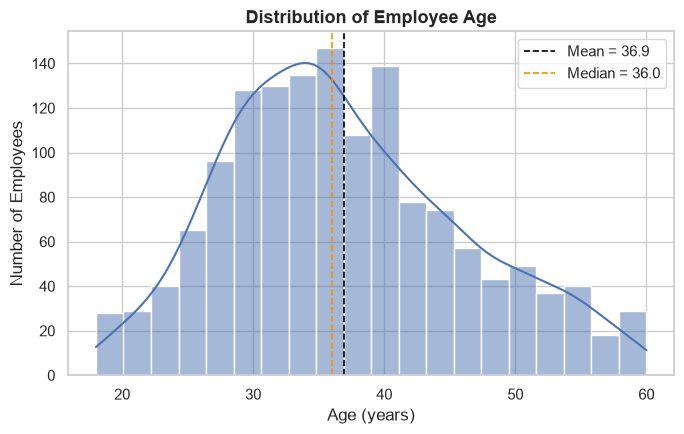

In [9]:
print("--- Age summary ---")
print(df_clean["Age"].describe().round(1))
print(f"\nSkewness: {df_clean['Age'].skew():.2f}")

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.histplot(data=df_clean, x="Age", bins=20, kde=True, color="#4C72B0", ax=ax)
ax.axvline(df_clean["Age"].mean(), color="black", linestyle="--", linewidth=1.2,
           label=f"Mean = {df_clean['Age'].mean():.1f}")
ax.axvline(df_clean["Age"].median(), color="darkorange", linestyle="--", linewidth=1.2,
           label=f"Median = {df_clean['Age'].median():.1f}")
ax.set_title("Distribution of Employee Age", fontsize=13, fontweight="bold")
ax.set_xlabel("Age (years)")
ax.set_ylabel("Number of Employees")
ax.legend()
plt.tight_layout()
plt.show()

### 2.4 Distribution of MonthlyIncome

Unlike Age, the summary table already hinted `MonthlyIncome` is right-skewed
(mean > median). We'll look at both a histogram/KDE and a boxplot — the boxplot
specifically to check for statistical outliers using the IQR method.

--- MonthlyIncome summary ---
count     1470.0
mean      6502.9
std       4708.0
min       1009.0
25%       2911.0
50%       4919.0
75%       8379.0
max      19999.0
Name: MonthlyIncome, dtype: float64

Skewness: 1.37

IQR = 5468, upper fence = 16581
Employees above upper fence (statistical outliers): 114 (7.8%)


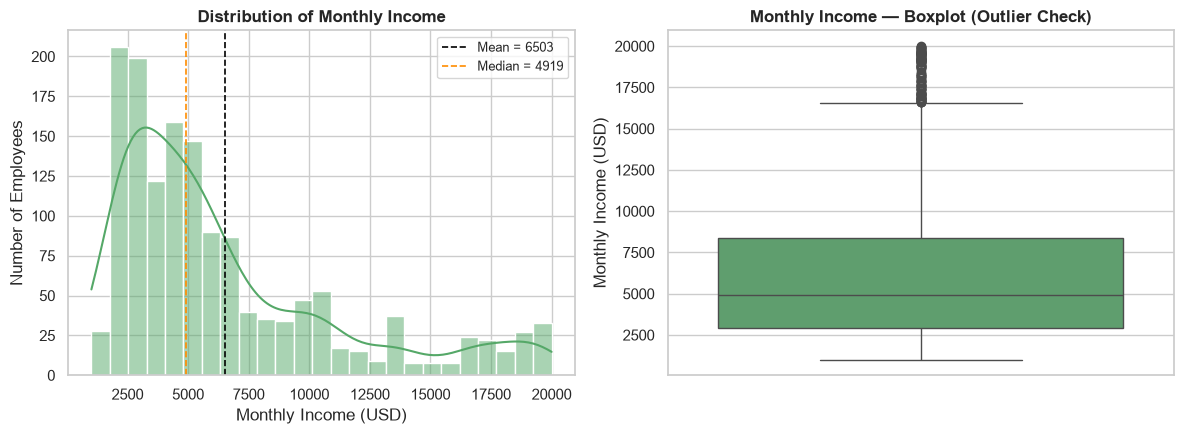

In [10]:
print("--- MonthlyIncome summary ---")
print(df_clean["MonthlyIncome"].describe().round(1))
print(f"\nSkewness: {df_clean['MonthlyIncome'].skew():.2f}")

# IQR outlier check
q1, q3 = df_clean["MonthlyIncome"].quantile([0.25, 0.75])
iqr = q3 - q1
upper_fence = q3 + 1.5 * iqr
outliers = df_clean[df_clean["MonthlyIncome"] > upper_fence]
print(f"\nIQR = {iqr:.0f}, upper fence = {upper_fence:.0f}")
print(f"Employees above upper fence (statistical outliers): {len(outliers)} ({len(outliers)/len(df_clean)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(data=df_clean, x="MonthlyIncome", bins=25, kde=True, color="#55A868", ax=axes[0])
axes[0].axvline(df_clean["MonthlyIncome"].mean(), color="black", linestyle="--", linewidth=1.2,
                label=f"Mean = {df_clean['MonthlyIncome'].mean():.0f}")
axes[0].axvline(df_clean["MonthlyIncome"].median(), color="darkorange", linestyle="--", linewidth=1.2,
                label=f"Median = {df_clean['MonthlyIncome'].median():.0f}")
axes[0].set_title("Distribution of Monthly Income", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Monthly Income (USD)")
axes[0].set_ylabel("Number of Employees")
axes[0].legend(fontsize=9)

sns.boxplot(data=df_clean, y="MonthlyIncome", color="#55A868", ax=axes[1])
axes[1].set_title("Monthly Income — Boxplot (Outlier Check)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("Monthly Income (USD)")

plt.tight_layout()
plt.show()

### 2.5 Categorical variables: overview

Quick value counts for every categorical column — this tells us how balanced each
category is, which matters later for bivariate comparisons (a category with very few
employees will produce noisy, unreliable comparisons).

In [11]:
cat_cols = df_clean.select_dtypes(include=["object", "string"]).columns.drop("Attrition")
for col in cat_cols:
    print(f"--- {col} ---")
    counts = df_clean[col].value_counts()
    pct = df_clean[col].value_counts(normalize=True) * 100
    summary = pd.DataFrame({"count": counts, "pct": pct.round(1)})
    print(summary)
    print()

--- BusinessTravel ---
                   count   pct
BusinessTravel                
Travel_Rarely       1043  71.0
Travel_Frequently    277  18.8
Non-Travel           150  10.2

--- Department ---
                        count   pct
Department                         
Research & Development    961  65.4
Sales                     446  30.3
Human Resources            63   4.3

--- EducationField ---
                  count   pct
EducationField               
Life Sciences       606  41.2
Medical             464  31.6
Marketing           159  10.8
Technical Degree    132   9.0
Other                82   5.6
Human Resources      27   1.8

--- Gender ---
        count   pct
Gender             
Male      882  60.0
Female    588  40.0

--- JobRole ---
                           count   pct
JobRole                               
Sales Executive              326  22.2
Research Scientist           292  19.9
Laboratory Technician        259  17.6
Manufacturing Director       145   9.9
Healthcare 

### 2.6 Key categorical distributions: Department and JobRole

Visualizing the two most structurally important categorical variables — where
employees sit in the organization. This also makes the small-group issue (HR being
much smaller than the other groups) immediately visible rather than just a number
in a table.

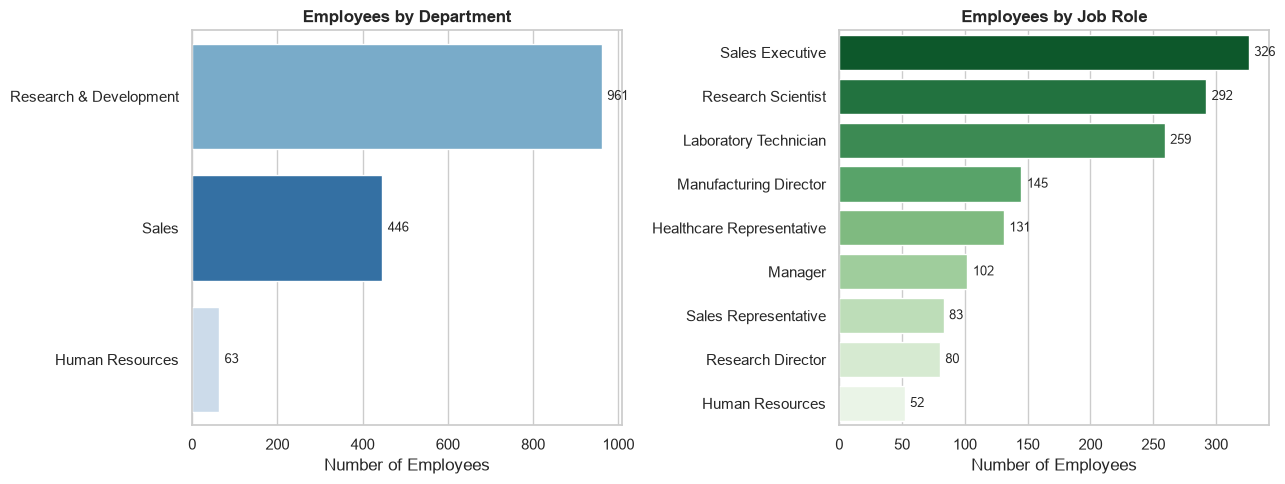

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

dept_order = df_clean["Department"].value_counts().index
sns.countplot(data=df_clean, y="Department", order=dept_order, hue="Department",
              legend=False, palette="Blues_r", ax=axes[0])
axes[0].set_title("Employees by Department", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Number of Employees")
axes[0].set_ylabel("")
for p in axes[0].patches:
    width = p.get_width()
    axes[0].annotate(f"{int(width)}", (width, p.get_y() + p.get_height()/2),
                      ha="left", va="center", fontsize=9, xytext=(4, 0),
                      textcoords="offset points")

role_order = df_clean["JobRole"].value_counts().index
sns.countplot(data=df_clean, y="JobRole", order=role_order, hue="JobRole",
              legend=False, palette="Greens_r", ax=axes[1])
axes[1].set_title("Employees by Job Role", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of Employees")
axes[1].set_ylabel("")
for p in axes[1].patches:
    width = p.get_width()
    axes[1].annotate(f"{int(width)}", (width, p.get_y() + p.get_height()/2),
                      ha="left", va="center", fontsize=9, xytext=(4, 0),
                      textcoords="offset points")

plt.tight_layout()
plt.show()

## 3. Bivariate Analysis

### 3.1 Correlation heatmap (numeric variables)

Before comparing specific variables to Attrition, a correlation heatmap gives us an
overview of how the numeric variables relate to *each other*. This helps spot
redundant variables (e.g. tenure-related fields that move together) and flags which
numeric variables are worth a closer look against Attrition.

**Important:** correlation measures linear association, not causation. A strong
correlation here just means two variables tend to move together — it says nothing
about which one drives the other, or whether both are driven by a third factor.

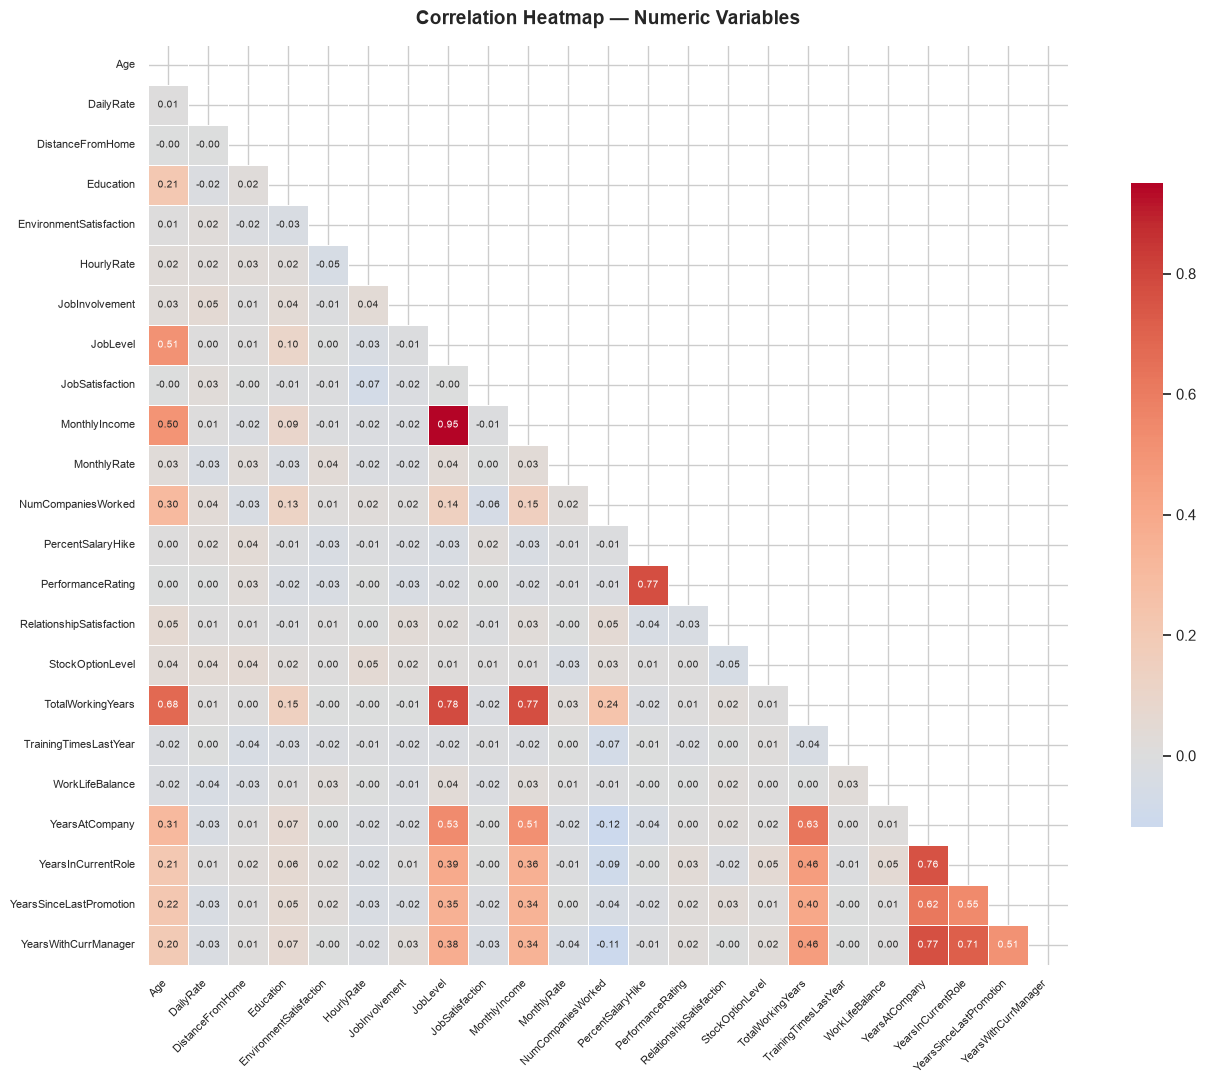

--- Top 10 strongest correlations ---
                   Var1               Var2  Correlation
          MonthlyIncome           JobLevel     0.950300
      TotalWorkingYears           JobLevel     0.782208
      PerformanceRating  PercentSalaryHike     0.773550
      TotalWorkingYears      MonthlyIncome     0.772893
   YearsWithCurrManager     YearsAtCompany     0.769212
     YearsInCurrentRole     YearsAtCompany     0.758754
   YearsWithCurrManager YearsInCurrentRole     0.714365
      TotalWorkingYears                Age     0.680381
         YearsAtCompany  TotalWorkingYears     0.628133
YearsSinceLastPromotion     YearsAtCompany     0.618409


In [15]:
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.7},
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation Heatmap — Numeric Variables", fontsize=14, fontweight="bold", pad=15)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Top correlated pairs (excluding self-correlation)
corr_pairs = corr_matrix.where(~mask).stack().reset_index()
corr_pairs.columns = ["Var1", "Var2", "Correlation"]
corr_pairs = corr_pairs[corr_pairs["Var1"] != corr_pairs["Var2"]]
top_corr = corr_pairs.reindex(corr_pairs["Correlation"].abs().sort_values(ascending=False).index).head(10)
print("--- Top 10 strongest correlations ---")
print(top_corr.to_string(index=False))

### 3.2 MonthlyIncome by Attrition

Does income differ between employees who left and those who stayed? A boxplot
compares the full distribution (not just the average) across the two groups, and
we back it up with the actual median values since income is right-skewed.

--- MonthlyIncome by Attrition ---
           median    mean  count
Attrition                       
No         5204.0  6832.7   1233
Yes        3202.0  4787.1    237


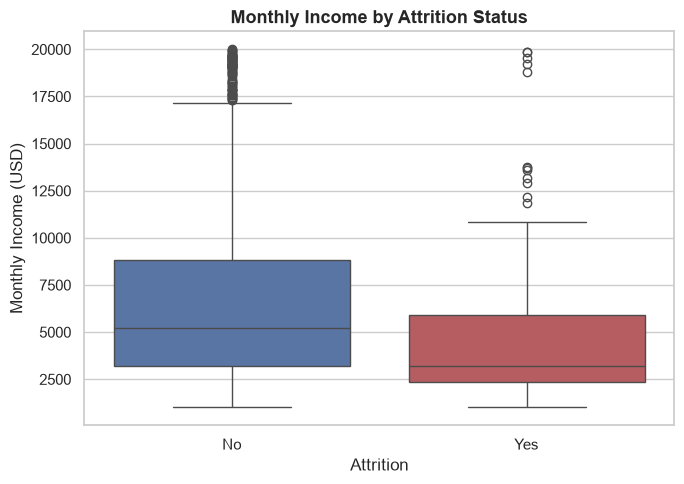

In [17]:
income_by_attrition = df_clean.groupby("Attrition")["MonthlyIncome"].agg(["median", "mean", "count"]).round(1)
print("--- MonthlyIncome by Attrition ---")
print(income_by_attrition)

fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_clean, x="Attrition", order=["No", "Yes"], y="MonthlyIncome",
            hue="Attrition", hue_order=["No", "Yes"], palette=["#4C72B0", "#C44E52"],
            legend=False, ax=ax)
ax.set_title("Monthly Income by Attrition Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Attrition")
ax.set_ylabel("Monthly Income (USD)")
plt.tight_layout()
plt.show()

### 3.3 OverTime vs Attrition

Both categorical. Since the two Attrition groups are very unequal in size (1,233 vs
237), we compare **attrition rate within each OverTime group** — i.e. what
percentage of "OverTime=Yes" employees left, vs what percentage of "OverTime=No"
employees left — rather than raw counts, which would be misleading.


--- Counts ---
Attrition   No  Yes
OverTime           
No         944  110
Yes        289  127

--- Attrition rate within each OverTime group (%) ---
Attrition    No   Yes
OverTime             
No         89.6  10.4
Yes        69.5  30.5


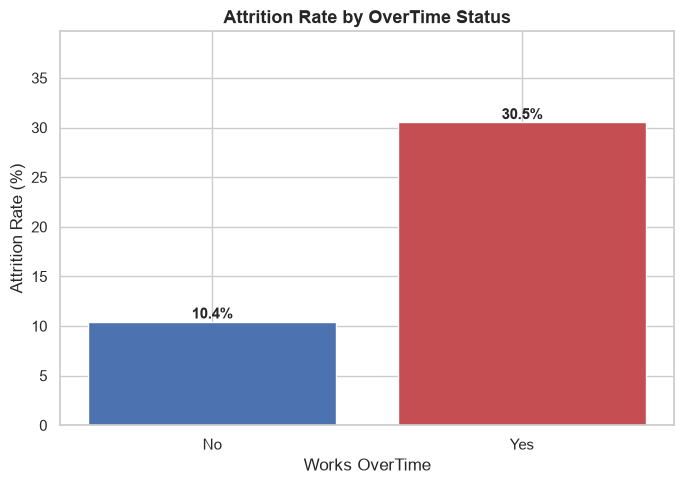

In [19]:
crosstab_counts = pd.crosstab(df_clean["OverTime"], df_clean["Attrition"])
crosstab_pct = pd.crosstab(df_clean["OverTime"], df_clean["Attrition"], normalize="index") * 100
print("--- Counts ---")
print(crosstab_counts)
print("\n--- Attrition rate within each OverTime group (%) ---")
print(crosstab_pct.round(1))

fig, ax = plt.subplots(figsize=(7, 5))
attrition_rate = df_clean.groupby("OverTime")["Attrition"].apply(lambda s: (s == "Yes").mean() * 100)
attrition_rate = attrition_rate.reindex(["No", "Yes"])
bars = ax.bar(attrition_rate.index, attrition_rate.values, color=["#4C72B0", "#C44E52"])
ax.set_title("Attrition Rate by OverTime Status", fontsize=13, fontweight="bold")
ax.set_xlabel("Works OverTime")
ax.set_ylabel("Attrition Rate (%)")
ax.set_ylim(0, attrition_rate.max() * 1.3)
for bar, val in zip(bars, attrition_rate.values):
    ax.annotate(f"{val:.1f}%", (bar.get_x() + bar.get_width()/2, val),
                ha="center", va="bottom", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.show()